In [1]:
import re
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

# EVAL_CSV_PATH = Path("eval_results/eval_meta-llama-llama-4-scout-17b-16e-instruct_20260306_152328.csv")
# EVAL_CSV_PATH = Path("eval_results/eval_claude-sonnet-4-5-20250929_20260305_233139.csv")
EVAL_CSV_PATH = Path("eval_results/eval_gpt-5-mini_20260311_114220.csv") # diff!!
# EVAL_CSV_PATH = Path("eval_results/eval_gemini-3-pro-preview_20260311_170420.csv")

with open("category.json", encoding="utf-8") as f:
    CATEGORY_MAP = json.load(f)

SUB_TO_CAT = {}
for cat, subs in CATEGORY_MAP.items():
    for sub in subs:
        SUB_TO_CAT[sub] = cat

VERBS = ["build", "create", "construct"]

def extract_verb(prompt: str) -> str:
    low = prompt.lower()
    for v in VERBS:
        if re.search(rf'\b{v}\b', low):
            return v
    return "other"

def extract_subcat(check_fn: str) -> str:
    """eval_code.material.is_corner_material_equal_to → material"""
    parts = check_fn.split(".")
    return parts[1] if len(parts) >= 3 else parts[-1]

df = pd.read_csv(EVAL_CSV_PATH)
df["verb"] = df["prompt_text"].apply(extract_verb)
df["subcat"] = df["check_fn"].apply(extract_subcat)
df["eval_cat"] = df["subcat"].map(SUB_TO_CAT).fillna("unknown")

print(f"File:  {EVAL_CSV_PATH.name}")
print(f"Rows:  {len(df)}")
print(f"Verbs: {df['verb'].value_counts().to_dict()}")
print(f"Eval categories: {sorted(df['eval_cat'].unique())}")

File:  eval_gpt-5-mini_20260311_114220.csv
Rows:  3530
Verbs: {'build': 1118, 'construct': 870, 'create': 854, 'other': 688}
Eval categories: ['accuracy', 'planning', 'safety']


## Per-Row Pass Rate by Verb × Eval Category

Each row in the CSV is one `(run, check_fn)` pair.
We compute **mean `passed`** grouped by `(verb, eval_cat)`.

In [2]:
verbs_in_data = [v for v in VERBS if v in df["verb"].values]

# ── 1. Per-check pass rate: verb × eval_cat ──
agg = (
    df.groupby(["verb", "eval_cat"])["passed"]
    .agg(["mean", "count", "sum"])
    .rename(columns={"mean": "pass_rate", "count": "n_checks", "sum": "n_passed"})
    .reset_index()
)
agg["n_passed"] = agg["n_passed"].astype(int)

pivot = agg.pivot(index="eval_cat", columns="verb", values="pass_rate")[verbs_in_data]
pivot_n = agg.pivot(index="eval_cat", columns="verb", values="n_checks")[verbs_in_data]

display(Markdown("### Check-Level Pass Rate  (mean of `passed` per check)"))
styled = (
    pivot.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None)
)
display(styled)

display(Markdown("### Number of Checks per Cell"))
display(pivot_n.style.format("{:.0f}"))

### Check-Level Pass Rate  (mean of `passed` per check)

verb,build,create,construct
eval_cat,,,
accuracy,62.8%,66.3%,67.4%
planning,44.5%,89.0%,86.9%
safety,63.8%,66.0%,52.4%


### Number of Checks per Cell

verb,build,create,construct
eval_cat,,,
accuracy,758,632,644
planning,96,48,48
safety,264,174,178


## Per-Problem (run_idx) Aggregate

A problem **passes** an eval category only when **all** checks in that category pass (`passed >= 1.0`).
We then report the fraction of problems that pass, grouped by verb.

In [3]:
# ── 2. Per-problem aggregate: a problem passes an eval_cat
#       only if ALL checks in that category have passed >= 1.0 ──
prob_rows = []
for (run_idx, verb), grp in df.groupby(["run_idx", "verb"]):
    row = {"run_idx": run_idx, "verb": verb}
    for cat in sorted(df["eval_cat"].unique()):
        cat_checks = grp[grp["eval_cat"] == cat]
        if len(cat_checks) == 0:
            continue
        row[cat] = int((cat_checks["passed"] >= 1.0).all())
    prob_rows.append(row)

prob_df = pd.DataFrame(prob_rows)

cat_cols = [c for c in prob_df.columns if c not in ("run_idx", "verb")]
prob_agg = prob_df.groupby("verb")[cat_cols].agg(["mean", "count"])

display(Markdown("### Problem-Level Pass Rate  (all checks in category must pass)"))
table_rows = []
for cat in cat_cols:
    row = {"eval_category": cat}
    for v in verbs_in_data:
        if v in prob_agg.index:
            rate = prob_agg.loc[v, (cat, "mean")]
            cnt = prob_agg.loc[v, (cat, "count")]
            row[v] = f"{rate:.1%}  (n={int(cnt)})"
        else:
            row[v] = "—"
    table_rows.append(row)

summary_df = pd.DataFrame(table_rows).set_index("eval_category")
display(summary_df)

### Problem-Level Pass Rate  (all checks in category must pass)

,build,create,construct
eval_category,,,
accuracy,35.2% (n=233),40.7% (n=167),38.6% (n=171)
planning,37.5% (n=96),75.0% (n=48),72.9% (n=48)
safety,62.6% (n=257),64.1% (n=167),50.9% (n=171)


## Subcategory Breakdown

Same per-check pass rate, but broken down by **subcategory** (material, shape, physical_plausibility, etc.) instead of top-level eval category.

In [4]:
# ── 3. Subcategory-level breakdown ──
sub_agg = (
    df.groupby(["verb", "eval_cat", "subcat"])["passed"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "pass_rate", "count": "n"})
    .reset_index()
    .sort_values(["eval_cat", "subcat", "verb"])
)

sub_pivot = sub_agg.pivot_table(
    index=["eval_cat", "subcat"], columns="verb", values="pass_rate"
)
if set(verbs_in_data).issubset(sub_pivot.columns):
    sub_pivot = sub_pivot[verbs_in_data]

display(Markdown("### Subcategory-Level Pass Rate"))
display(
    sub_pivot.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None)
)

### Subcategory-Level Pass Rate

## Visualization

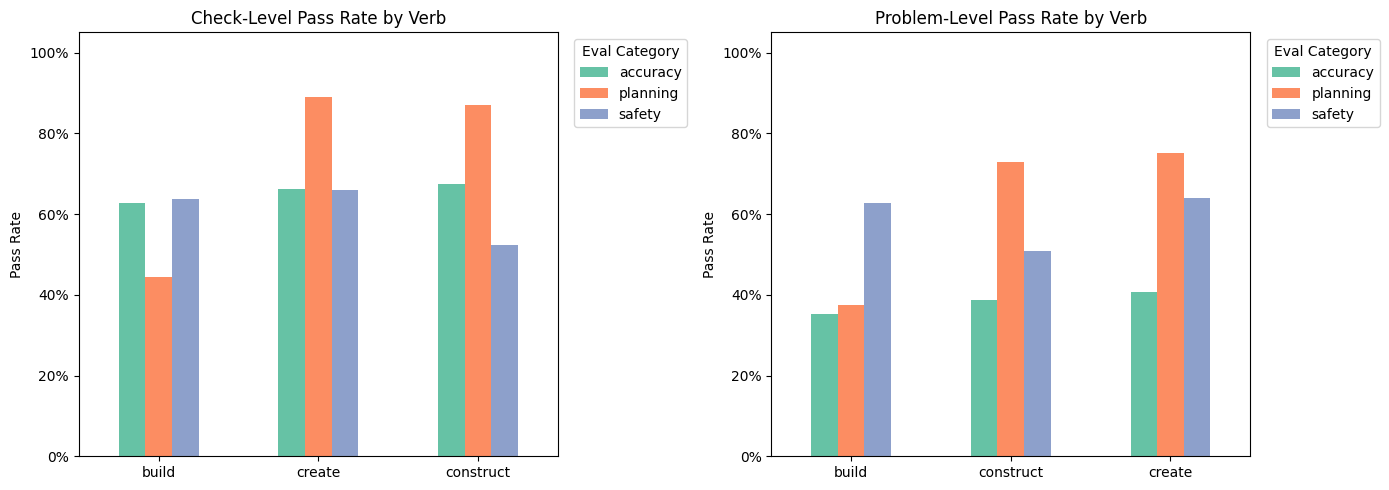

In [5]:
COLORS = {"build": "#4C72B0", "create": "#DD8452", "construct": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: check-level pass rate ──
ax = axes[0]
pivot_plot = pivot.T
pivot_plot.plot.bar(ax=ax, color=[plt.cm.Set2(i) for i in range(len(pivot_plot.columns))])
ax.set_title("Check-Level Pass Rate by Verb")
ax.set_ylabel("Pass Rate")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.legend(title="Eval Category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)

# ── Right: problem-level pass rate ──
ax2 = axes[1]
prob_rate = prob_df.groupby("verb")[cat_cols].mean()
prob_rate = prob_rate.loc[prob_rate.index.isin(verbs_in_data)]
prob_rate.plot.bar(ax=ax2, color=[plt.cm.Set2(i) for i in range(len(cat_cols))])
ax2.set_title("Problem-Level Pass Rate by Verb")
ax2.set_ylabel("Pass Rate")
ax2.set_xlabel("")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylim(0, 1.05)
ax2.legend(title="Eval Category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

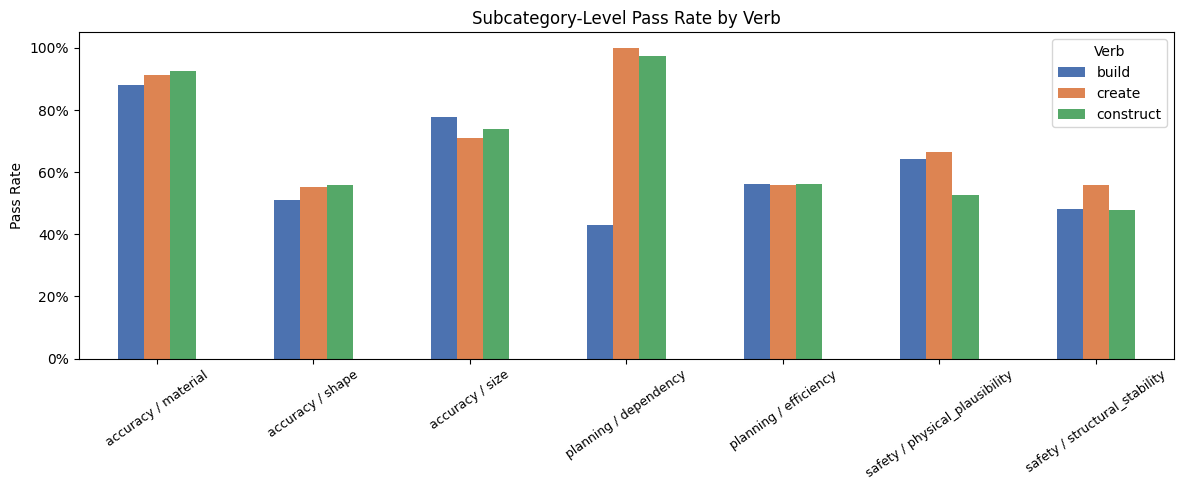

In [6]:
# ── Subcategory grouped bar chart ──
fig2, ax3 = plt.subplots(figsize=(12, 5))
sub_pivot_plot = sub_pivot.copy()
sub_pivot_plot.index = [f"{cat} / {sub}" for cat, sub in sub_pivot_plot.index]
sub_pivot_plot.plot.bar(ax=ax3, color=[COLORS.get(v, "#999") for v in sub_pivot_plot.columns])
ax3.set_title("Subcategory-Level Pass Rate by Verb")
ax3.set_ylabel("Pass Rate")
ax3.set_xlabel("")
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax3.set_ylim(0, 1.05)
ax3.legend(title="Verb")
ax3.tick_params(axis="x", rotation=35, labelsize=9)
plt.tight_layout()
plt.show()